# Iris Flower Classification Project
Exploratory Data Analysis (EDA) and Model Performance Comparison (kNN, Logistic Regression, Naive Bayes).

In [1]:
# Necessary Modules For Analysis & Modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis (EDA)

In [2]:
# Loading Dataset

flowers = pd.read_csv("Iris.csv")
flowers.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Summary statistics for numerical feature

flowers.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
# Inspect data structure, null values, and class balance

print(flowers.info(), "\n")
print(flowers.shape, "\n")
print(flowers["Species"].nunique(), "\n")
print(flowers.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB
None 

(150, 6) 

3 

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [5]:
# Drop 'Id' column as it carries no predictive value

clean_flowers = flowers.drop(columns = ["Id"])
clean_flowers.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## EDA Visualizations
Examine feature distributions, class separability, and multicollinearity using a 2x2 grid.

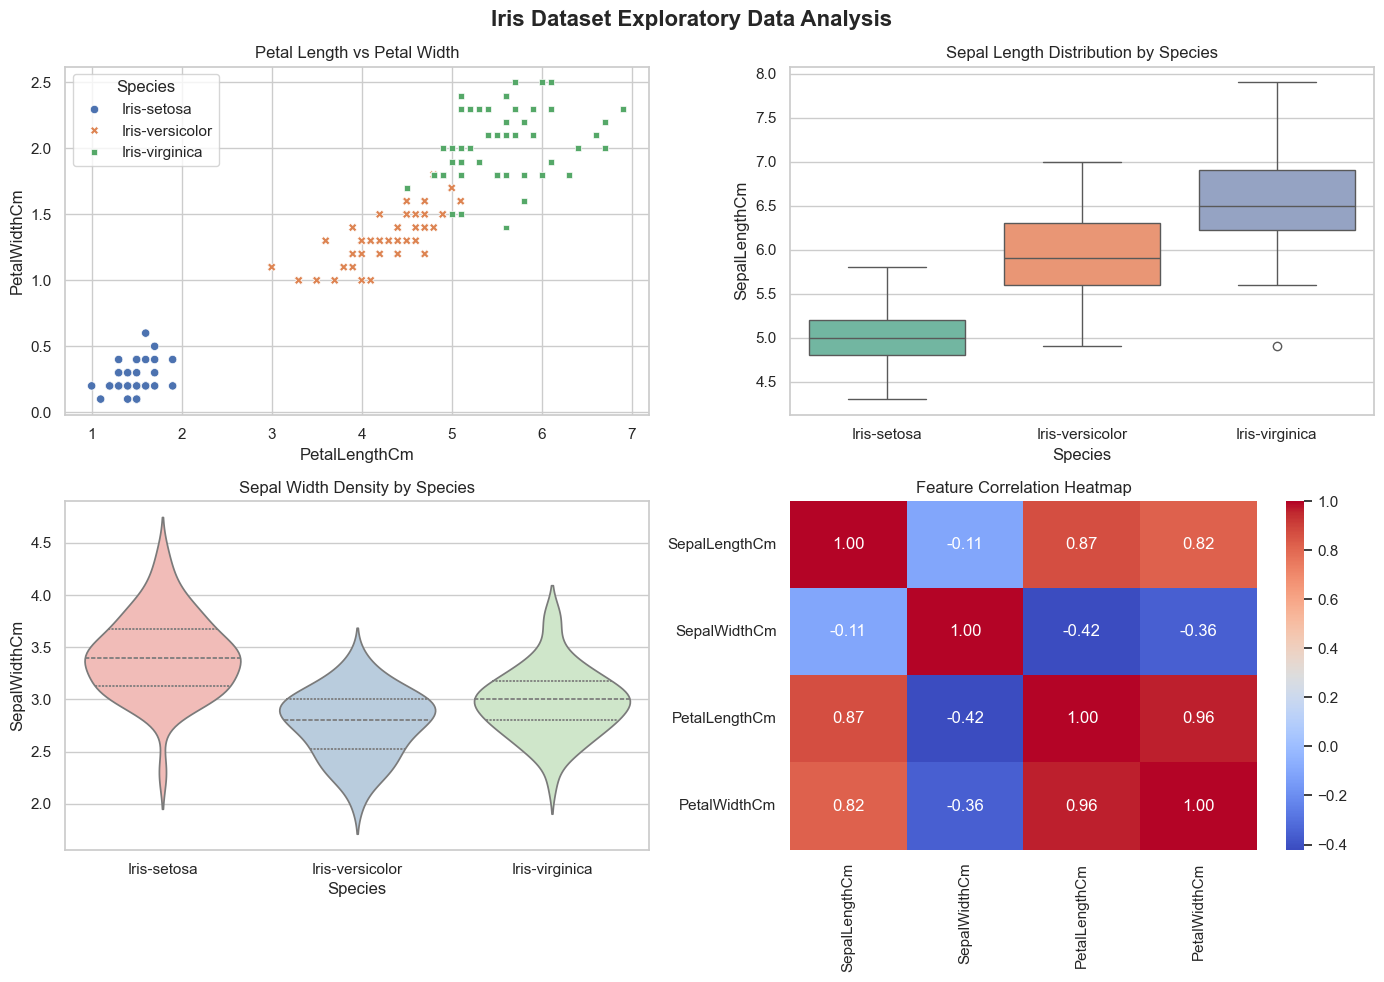

In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Iris Dataset Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Top-Left: Scatter Plot (Petal Length vs Petal Width)
sns.scatterplot(
    data=clean_flowers, 
    x='PetalLengthCm', 
    y='PetalWidthCm', 
    hue='Species', 
    style='Species', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Petal Length vs Petal Width', fontsize=12)

# Top-Right: Box Plot (Distribution of Sepal Length across Species)
sns.boxplot(
    data=clean_flowers, 
    x='Species', 
    y='SepalLengthCm',
    hue='Species',
    legend=False,
    palette='Set2', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Sepal Length Distribution by Species', fontsize=12)

# Bottom-Left: Violin Plot (Density distribution of Sepal Width)
sns.violinplot(
    data=clean_flowers, 
    x='Species', 
    y='SepalWidthCm', 
    hue='Species',
    legend=False,
    palette='Pastel1', 
    inner='quartile', 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Sepal Width Density by Species', fontsize=12)

# Bottom-Right: Correlation Heatmap
numeric_df = clean_flowers.drop(columns=['Species'], errors='ignore')
sns.heatmap(
    numeric_df.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    cbar=True, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Feature Correlation Heatmap', fontsize=12)


plt.tight_layout()
plt.show()

# Model Training & Evaluation
Training on 50% of the dataset and evaluating on the full dataset across 3 algorithms.

In [7]:
# Necessary Models For Training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [8]:
# Encoding the Species Column
le = LabelEncoder()
flowers['Species'] = le.fit_transform(flowers['Species'])
flowers.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
94,95,5.6,2.7,4.2,1.3,1
32,33,5.2,4.1,1.5,0.1,0
69,70,5.6,2.5,3.9,1.1,1
7,8,5.0,3.4,1.5,0.2,0
49,50,5.0,3.3,1.4,0.2,0
121,122,5.6,2.8,4.9,2.0,2
144,145,6.7,3.3,5.7,2.5,2
78,79,6.0,2.9,4.5,1.5,1
35,36,5.0,3.2,1.2,0.2,0
44,45,5.1,3.8,1.9,0.4,0


In [9]:
# Define Features and Target
X = flowers.drop(columns=['Id', 'Species'])
y = flowers['Species']

# Split data (50% Train, 50% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

 ### K-Nearest Neighbours (kNN)

In [10]:
# Training

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11, 13]}

classifierCV = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

classifierCV.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [11]:
# Evalution

y_pred_knn = classifierCV.predict(X)

print("Accuracy:", accuracy_score(y, y_pred_knn))
print("cm:\n", confusion_matrix(y, y_pred_knn))
print("classification report:\n", classification_report(y, y_pred_knn))

Accuracy: 0.9533333333333334
cm:
 [[50  0  0]
 [ 0 49  1]
 [ 0  6 44]]
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.89      0.98      0.93        50
           2       0.98      0.88      0.93        50

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150



### Simple Logistic Regression

In [12]:
# Training

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
# Testing

y_pred_log = log_reg.predict(X_all_scaled)

print("Accuracy:", accuracy_score(y, y_pred_log))
print("cm:\n", confusion_matrix(y, y_pred_log))
print("classification report:\n", classification_report(y, y_pred_log))

Accuracy: 0.96
cm:
 [[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



### Naive Bayes

In [14]:
# Training

nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [15]:
# Testing

y_pred_nb = nb.predict(X)

print("Accuracy:", accuracy_score(y, y_pred_nb))
print("cm:\n", confusion_matrix(y, y_pred_nb))
print("classification report:\n", classification_report(y, y_pred_nb))

Accuracy: 0.9533333333333334
cm:
 [[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.94      0.93        50
           2       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



# Conclusion & Summary

* **Performance:** All three algorithms (**kNN**, **Logistic Regression**, and **Gaussian Naive Bayes**) achieved **~95.33% accuracy** when trained on a 50% data split and tested across the dataset.
* **Class Separability:** *Iris-setosa* is 100% linearly separable across all models (F1-score = 1.00).
* **Model Choice:** Since all models performed identically well, **Logistic Regression** is the preferred choice for deployment due to its simplicity, speed, and efficiency.